In [1]:
from collections import defaultdict, Counter
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from graphviz import Digraph
import plotly.express as px
import pandas as pd
import json
import os


In [2]:
data_dir = "../data"
raw_dir = os.path.join(data_dir, "processed")
session_dir = os.path.join(raw_dir, "merged")
gameplay_dir = os.path.join(session_dir, "Gameplay")
traces_path = os.path.join(gameplay_dir, "traces.ndjson")


In [3]:
with open(traces_path, "r", encoding="utf-8") as f:
	print(repr(f.read()[:200]))
	

'{"actor": {"account": {"name": "684837aae48b5a00221a37c9_fwme", "homePage": "https://simva-beta.e-ucm.es"}}, "result": {"extensions": {"https://w3id.org/xapi/seriousgame/extensions/Sexuality": "hetero'


In [4]:
df = pd.read_json(traces_path, lines=True)
display(df.head())


,actor,result,stored,authority,verb,context,id,version,timestamp,object
0,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:45:15.365Z,"{'name': '684837aae48b5a00221a37c9_fwme', 'hom...","{'display': {'en-US': 'initialized'}, 'id': 'h...",{'contextActivities': {'category': [{'id': 'ht...,e8aa9f32-22db-4f33-bd7a-9f13dd73bf96,1.0.2,2025-06-11 10:42:58.869000+00:00,{'definition': {'name': {'en-US': 'serious-gam...
1,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:45:15.365Z,"{'name': '684837aae48b5a00221a37c9_fwme', 'hom...","{'display': {'en-US': 'accessed'}, 'id': 'http...",{'contextActivities': {'category': [{'id': 'ht...,a2af535f-67ed-4d74-91b1-2ed7071e195c,1.0.2,2025-06-11 10:42:59.082000+00:00,"{'definition': {'name': {'en-US': 'cutscene'},..."
2,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:45:15.365Z,"{'name': '684837aae48b5a00221a37c9_fwme', 'hom...","{'display': {'en-US': 'accessed'}, 'id': 'http...",{'contextActivities': {'category': [{'id': 'ht...,6f51b793-d7ee-4a30-9dc8-1838ba307ca6,1.0.2,2025-06-11 10:43:03.048000+00:00,"{'definition': {'name': {'en-US': 'area'}, 'de..."
3,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:44:31.798Z,"{'name': '684837aae48b5a00221a37c9_newj', 'hom...","{'display': {'en-US': 'initialized'}, 'id': 'h...",{'contextActivities': {'category': [{'id': 'ht...,78a674d5-2f92-4a02-be29-6f8fc06e3565,1.0.2,2025-06-11 10:43:03.271000+00:00,{'definition': {'name': {'en-US': 'serious-gam...
4,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:44:31.798Z,"{'name': '684837aae48b5a00221a37c9_newj', 'hom...","{'display': {'en-US': 'accessed'}, 'id': 'http...",{'contextActivities': {'category': [{'id': 'ht...,273af825-cc45-453b-ba1e-5b72f3eb7899,1.0.2,2025-06-11 10:43:03.486000+00:00,"{'definition': {'name': {'en-US': 'cutscene'},..."


In [5]:
traces = []
invalid_count = 0

with open(traces_path, "r", encoding="utf-8") as f:
	for line in f:
		line = line.strip()
		if line:
			try:
				traces.append(json.loads(line))
			except json.JSONDecodeError:
				invalid_count += 1

print("Total valid traces:", len(traces))
print("Total invalid traces:", invalid_count)


Total valid traces: 98930
Total invalid traces: 0


In [6]:
GAME_START_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/serious-game/GameStart"
GAME_END_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/serious-game/GameEnd"
GENDER_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Gender"
SEXUALITY_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Sexuality"


In [7]:
start_counts = Counter()
end_counts = Counter()

for trace in traces:
	user = trace["actor"]["account"]["name"]
	obj_id = trace.get("object", {}).get("id", "")

	if obj_id == GAME_START_OBJ_ID:
		start_counts[user] += 1
	elif obj_id == GAME_END_OBJ_ID:
		end_counts[user] += 1

print("Max starts per user:", max(start_counts.values()))
print("Max ends per user:", max(end_counts.values()))


Max starts per user: 1
Max ends per user: 1


In [8]:
users = set()

user_profile = defaultdict(lambda: {
	"gender": None,
	"sexuality": None,
})

for trace in traces:
	user = trace.get("actor", {}).get("account", {}).get("name")
	if user:
		users.add(user)

		result = trace.get("result", {})
		extensions = result.get("extensions", {}) or {}
		
		if user_profile[user]["gender"] is None:
			user_profile[user]["gender"] = extensions.get(GENDER_EXT_ID)
		
		if user_profile[user]["sexuality"] is None:
			user_profile[user]["sexuality"] = extensions.get(SEXUALITY_EXT_ID)

		obj_id = trace.get("object", {}).get("id", "")

print("Total users:", len(users))


Total users: 104


In [9]:
user_times = defaultdict(lambda: {
    "start": None,
    "end": None
})

for trace in traces:
    user = trace["actor"]["account"]["name"]
    obj_id = trace.get("object", {}).get("id", "")

    timestamp = datetime.fromisoformat(
        trace["timestamp"].replace("Z", "+00:00")
    )

    if obj_id == GAME_START_OBJ_ID:
        user_times[user]["start"] = timestamp

    elif obj_id == GAME_END_OBJ_ID:
        user_times[user]["end"] = timestamp
        

In [10]:
rows = []

for user, data in user_times.items():
    if data["start"] is not None and data["end"] is not None:
        duration = (
            data["end"] - data["start"]
        ).total_seconds() / 60

        rows.append({
            "user": user,
            "minutes": duration
        })

df_time = pd.DataFrame(rows)

display(df_time.head())


,user,minutes
0,684837aae48b5a00221a37c9_fwme,21.513583
1,684837aae48b5a00221a37c9_newj,15.685933
2,684837aae48b5a00221a37c9_vboy,19.186700
3,684837aae48b5a00221a37c9_ndkj,21.422683
4,684837aae48b5a00221a37c9_cgph,21.062167


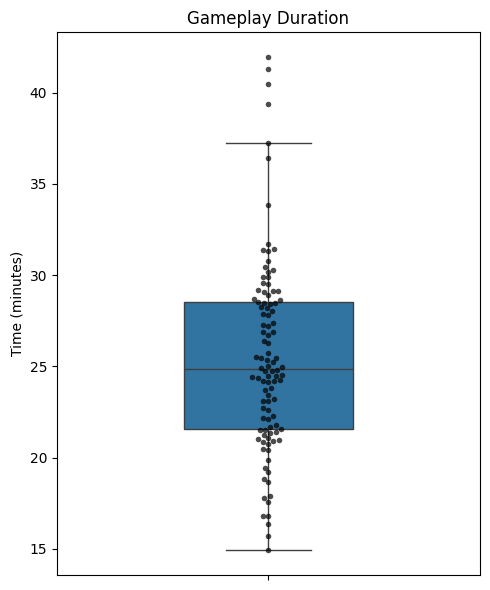

In [11]:
plt.figure(figsize=(5, 6))

sns.boxplot(
    y=df_time["minutes"],
    width=0.4,
    showfliers=False
)

sns.swarmplot(
    y=df_time["minutes"],
    color="black",
    size=4,
    alpha=0.7
)

plt.title("Gameplay Duration")
plt.ylabel("Time (minutes)")
plt.xlabel("")

plt.tight_layout()
plt.show()



In [ ]:
Q1 = df_time["minutes"].quantile(0.25)
Q3 = df_time["minutes"].quantile(0.75)

IQR = Q3 - Q1

# https://www.geeksforgeeks.org/data-analysis/box-plot/
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_time_clean = df_time[
    (df_time["minutes"] >= lower) &
    (df_time["minutes"] <= upper)
]

print("Original:", len(df_time))
print("Without outliers:", len(df_time_clean))


Original: 104
Without outliers: 100


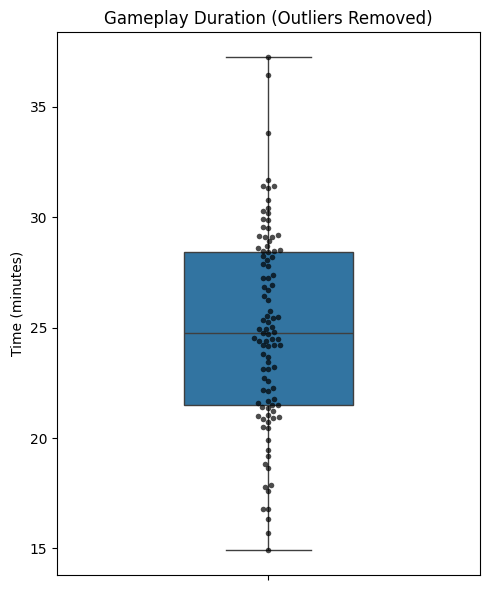

In [13]:
plt.figure(figsize=(5, 6))

sns.boxplot(
    y=df_time_clean["minutes"],
    width=0.4,
    showfliers=False
)

sns.swarmplot(
    y=df_time_clean["minutes"],
    color="black",
    size=4,
    alpha=0.7
)

plt.title("Gameplay Duration (Outliers Removed)")
plt.ylabel("Time (minutes)")
plt.xlabel("")

plt.tight_layout()
plt.show()


In [14]:
df = pd.DataFrame.from_dict(user_profile, orient="index").reset_index()
df.rename(columns={"index": "user"}, inplace=True)

print(df.head())


                            user  gender     sexuality
0  684837aae48b5a00221a37c9_fwme    male  heterosexual
1  684837aae48b5a00221a37c9_newj    male  heterosexual
2  684837aae48b5a00221a37c9_vboy    male  heterosexual
3  684837aae48b5a00221a37c9_ndkj  female  heterosexual
4  684837aae48b5a00221a37c9_cgph  female  heterosexual


sexuality  bisexual  heterosexual  homosexual
gender                                       
female            1            32          17
male              2            39          13


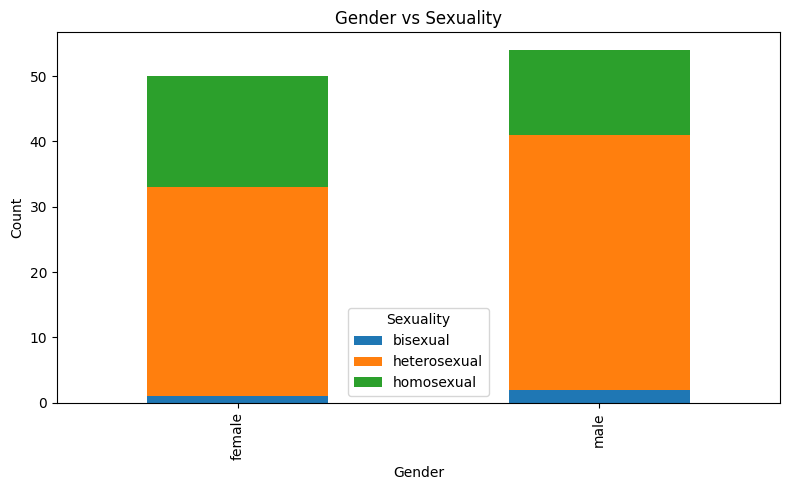

In [15]:
cross = pd.crosstab(df["gender"], df["sexuality"])

print(cross)

cross.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Gender vs Sexuality")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Sexuality")
plt.tight_layout()
plt.show()


In [16]:
NODE_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Node"
RESPONSE_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Response"
CHOICE_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/OptionSelect"


In [17]:
node_counts = defaultdict(int)
node_response_counts = defaultdict(Counter)

for trace in traces:
	obj_id = trace.get("object", {}).get("id", "")
	
	if obj_id == CHOICE_OBJ_ID:
		extensions = trace.get("result", {}).get("extensions", {}) or {}

		node = extensions.get(NODE_EXT_ID)
		response = extensions.get(RESPONSE_EXT_ID)

		if node:
			node_counts[node] += 1

		if node and response:
			node_response_counts[node][response] += 1
			
print("Number of choice nodes:", len(node_counts))


Number of choice nodes: 53


In [18]:
rows = []

for node in node_counts:
	rows.append({
		"node": node,
		"total_selections": node_counts[node],
		"unique_choices": len(node_response_counts[node])
	})

df_nodes = pd.DataFrame(rows)

display(df_nodes.head())


,node,total_selections,unique_choices
0,Scene1Classroom.part2.thanks,119,4
1,Scene1Lunch1.main.choices,117,2
2,Scene1Lunch1.phone.choices,115,1
3,Scene1Bedroom1.computer1.choices,115,2
4,Scene1Bedroom1.computer1.choices2,115,2


In [19]:
most_chosen = {}

for node, counter in node_response_counts.items():
	option, count = counter.most_common(1)[0]
	most_chosen[node] = {
		"option": option,
		"count": count
	}

for node, data in most_chosen.items():
	print(node, "->", data["option"])
	

Scene1Classroom.part2.thanks -> Igualmente, encantada de conocerte *sonríes*.
Scene1Lunch1.main.choices -> Contarles sobre mi día.
Scene1Lunch1.phone.choices -> Mandar la foto de Toni y Mila.
Scene1Bedroom1.computer1.choices -> Contestar amablemente.
Scene1Bedroom1.computer1.choices2 -> Su perrita.
Scene1Bedroom1.computer2.root -> Un par de años.
Scene1Bedroom1.computer2.choices2 -> 2º de la ESO
Scene1Bedroom1.computer2.choices3 -> Me voy ya, que es tarde
Scene1Bedroom1.bed.goToSleep -> Sí.
Scene1Bedroom2.computer.choices -> No contarle mi día.
Scene1Bedroom2.computer.choices2 -> Guay.
Scene1Bedroom2.computer.choices3 -> Ver un vídeo.
Scene1Bedroom2.bed.goToSleep -> Sí.
Scene2Break.part2.choice -> ¡De una!
Scene2Bedroom.computer.reply -> Responder.
Scene2Bedroom.phone.choices -> Bueno, me voy a dormir.
Scene2Bedroom.bed.goToSleep -> Sí.
Scene3Break.conversation1.choices -> Seguir escuchando.
Scene3Break.conversation2.choices3 -> Sobre el profesor...
Scene3Bedroom.main.choices -> Me gus

In [20]:
rows = []

for node, counter in node_response_counts.items():
	option, count = counter.most_common(1)[0]
	total = sum(counter.values())

	rows.append({
		"node": node,
		"most_chosen": option,
		"count": count,
		"total": total,
	})

df_most = pd.DataFrame(rows)
df_most["short_node"] = df_most["node"].apply(lambda x: x.split(".")[-1])
df_most["percentage"] = (df_most["count"] / df_most["total"] * 100).round(2)

TEXT_LENGTH = 35

df_most["short_option"] = df_most["most_chosen"].apply(
	lambda x: x if len(x) <= TEXT_LENGTH else x[:TEXT_LENGTH] + "..."
)

display(df_most.head())


,node,most_chosen,count,total,short_node,percentage,short_option
0,Scene1Classroom.part2.thanks,"Igualmente, encantada de conocerte *sonríes*.",55,119,thanks,46.22,"Igualmente, encantada de conocerte ..."
1,Scene1Lunch1.main.choices,Contarles sobre mi día.,110,117,choices,94.02,Contarles sobre mi día.
2,Scene1Lunch1.phone.choices,Mandar la foto de Toni y Mila.,115,115,choices,100.00,Mandar la foto de Toni y Mila.
3,Scene1Bedroom1.computer1.choices,Contestar amablemente.,76,115,choices,66.09,Contestar amablemente.
4,Scene1Bedroom1.computer1.choices2,Su perrita.,95,115,choices2,82.61,Su perrita.


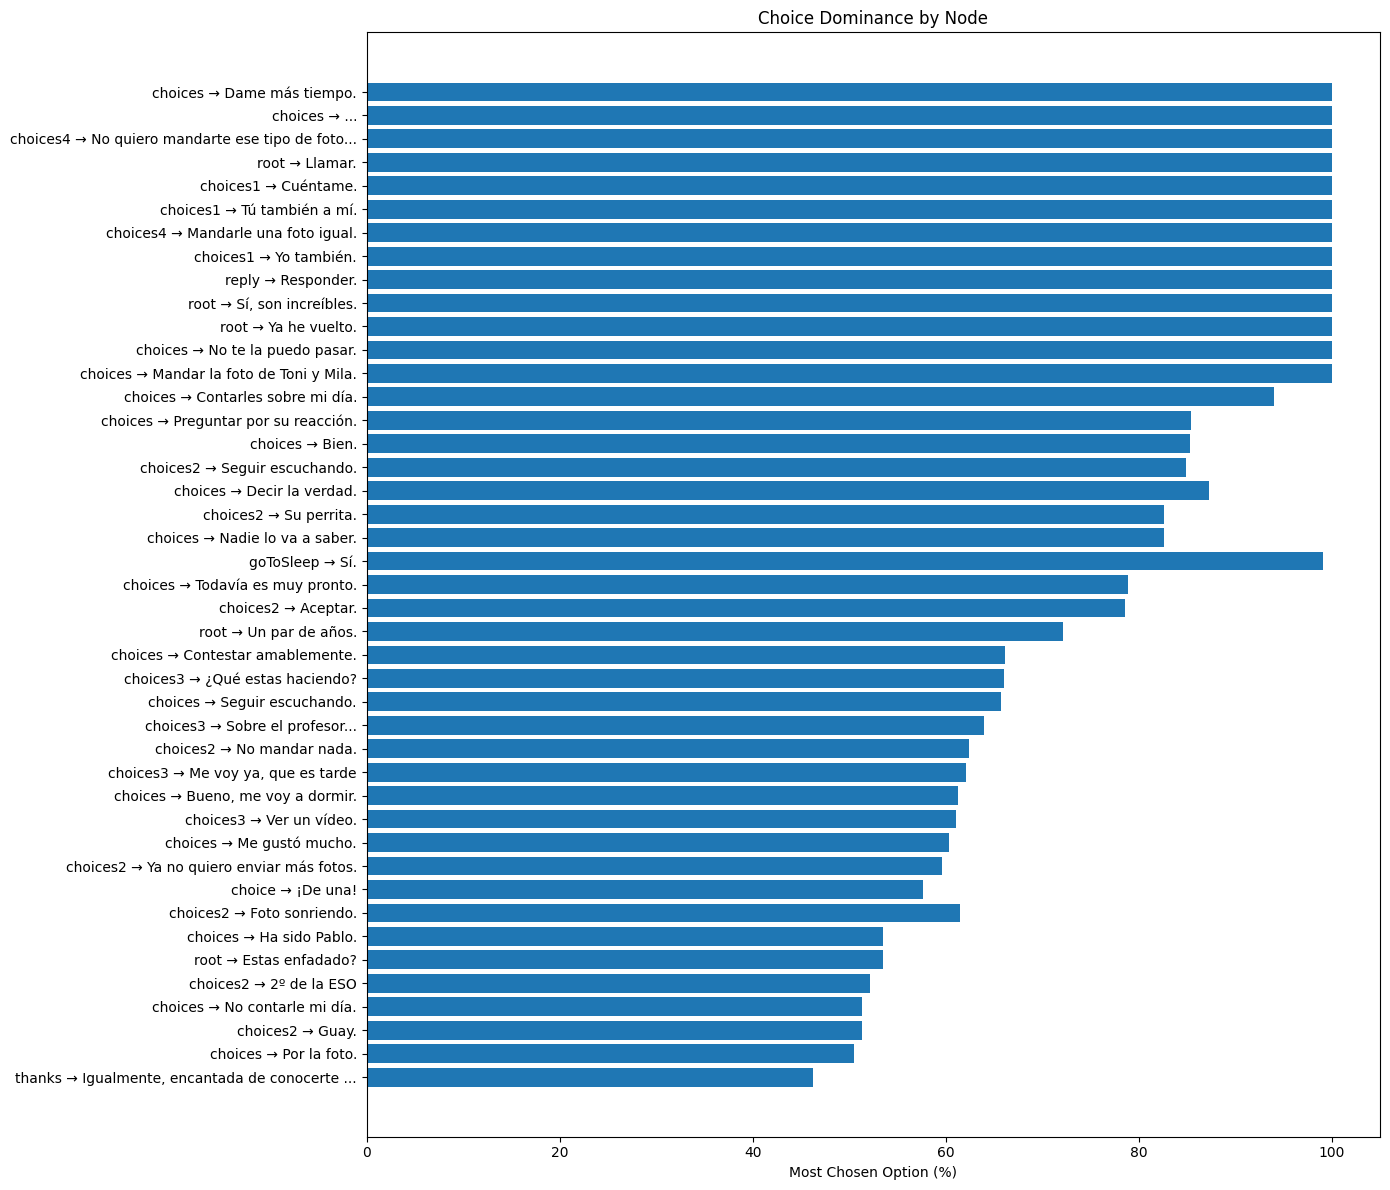

In [21]:
df_plot = df_most.sort_values("percentage")

labels = df_plot["short_node"] + " → " + df_plot["short_option"]

plt.figure(figsize=(14, 12))

plt.barh(labels, df_plot["percentage"])

plt.xlabel("Most Chosen Option (%)")
plt.title("Choice Dominance by Node")

plt.tight_layout()
plt.show()


In [22]:
target_nodes = {
	"Scene1Bedroom1.computer2.choices2": "school_year",
	"Scene1Lunch1.main.choices": "talk_parents_first_day_school",
	"Scene4Bedroom.phone.choices": "harassment_conflict_friend",
	"Scene4Garage.photo.choices": "suspicious_gift_photo",
	"Scene4Garage.interruption.choices": "stop_sending_gift_photo",
	"Scene5Livingroom.choices": "argument_with_harasser",
	"Scene6Bedroom.phone.choices2": "send_more_nudes",
	"Scene6BedroomRouteA1.phone.choices2": "agree_to_meet_harasser",
	"Scene6LunchRouteB.interruption.choices": "confess_to_parents"
}


In [ ]:
node_response_counts = defaultdict(Counter)

for trace in traces:
	obj_id = trace.get("object", {}).get("id", "")

	if obj_id == CHOICE_OBJ_ID:
		extensions = trace.get("result", {}).get("extensions", {})

		node = extensions.get(NODE_EXT_ID)
		response = extensions.get(RESPONSE_EXT_ID)

		if node in target_nodes and response:
			node_response_counts[node][response] += 1
			
print(len(node_response_counts))
			

9


In [24]:
print(len(node_response_counts))


9


In [25]:
print(node_response_counts)


defaultdict(<class 'collections.Counter'>, {'Scene1Lunch1.main.choices': Counter({'Contarles sobre mi día.': 110, 'No contarles sobre mi día.': 7}), 'Scene1Bedroom1.computer2.choices2': Counter({'2º de la ESO': 60, '4º de la ESO': 38, '3º de la ESO': 9, '1º de la ESO': 8}), 'Scene4Garage.photo.choices': Counter({'Decir la verdad.': 91, 'Mentir.': 17}), 'Scene4Garage.interruption.choices': Counter({'Nadie lo va a saber.': 90, 'No te incumbe.': 19}), 'Scene4Bedroom.phone.choices': Counter({'Por la foto.': 55, 'Prefiero no hablar de ello.': 34, 'Por nuestra relación.': 20}), 'Scene5Livingroom.choices': Counter({'Preguntar por su reacción.': 94, 'Ofenderse.': 16}), 'Scene6Bedroom.phone.choices2': Counter({'Ya no quiero enviar más fotos.': 62, 'Enviar otra foto.': 42}), 'Scene6BedroomRouteA1.phone.choices2': Counter({'Aceptar.': 33, 'Negarse.': 9}), 'Scene6LunchRouteB.interruption.choices': Counter({'Decir la verdad.': 62, 'Mentir.': 9})})


In [26]:
rows = []

for node, keywords in target_nodes.items():
	total = sum(node_response_counts[node].values())

	for option, count in node_response_counts[node].items():
		rows.append({
			"node": node,
			"keywords": keywords,
			"option": option,
			"count": count,
			"total": total,
		})

df_nodes = pd.DataFrame(rows)

df_nodes["percentage"] = df_nodes["count"] / df_nodes["total"]

# Columnas usadas para ordenar --> "node", "percentage"
# Orden de cada columna --> "node" (ascendente), "percentage" (descendente)
# inplace=True --> modifica df_nodes directamente
df_nodes.sort_values(["node", "percentage"], ascending=[True, False], inplace=True)

display(df_nodes)


,node,keywords,option,count,total,percentage
0,Scene1Bedroom1.computer2.choices2,school_year,2º de la ESO,60,115,0.521739
1,Scene1Bedroom1.computer2.choices2,school_year,4º de la ESO,38,115,0.330435
2,Scene1Bedroom1.computer2.choices2,school_year,3º de la ESO,9,115,0.078261
3,Scene1Bedroom1.computer2.choices2,school_year,1º de la ESO,8,115,0.069565
4,Scene1Lunch1.main.choices,talk_parents_first_day_school,Contarles sobre mi día.,110,117,0.940171
5,Scene1Lunch1.main.choices,talk_parents_first_day_school,No contarles sobre mi día.,7,117,0.059829
6,Scene4Bedroom.phone.choices,harassment_conflict_friend,Por la foto.,55,109,0.504587
7,Scene4Bedroom.phone.choices,harassment_conflict_friend,Prefiero no hablar de ello.,34,109,0.311927
8,Scene4Bedroom.phone.choices,harassment_conflict_friend,Por nuestra relación.,20,109,0.183486
11,Scene4Garage.interruption.choices,stop_sending_gift_photo,Nadie lo va a saber.,90,109,0.825688


In [27]:
fig = px.bar(
	df_nodes,
	x="percentage",
	y="keywords",
	color="option",
	orientation="h",
    text="option",
	hover_data={
		"percentage": ":.2f",
		"keywords": False
	},
	title="Choice Distribution per Node"
)

fig.update_layout(
    barmode="stack",
    yaxis_title="",
    xaxis_title="Percentage",
    height=900,
    showlegend=False,
    xaxis=dict(range=[0, 1], tickformat=".0%")
)

fig.update_traces(
    textposition="inside"
)

fig.show()


In [28]:
target_nodes = {
	"Scene6Bedroom.phone.choices2": "send_more_nudes",
	"Scene6BedroomRouteA1.phone.choices2": "agree_to_meet_harasser",
	"Scene6LunchRouteB.interruption.choices": "confess_to_parents"
}


In [29]:
user_traces = defaultdict(list)

for trace in traces:
    user = trace.get("actor", {}).get("account", {}).get("name")
    if user:
        user_traces[user].append(trace)

END_NODES = {
    "END_MEET": "meet_harasser_in_person",
    "END_TELL": "confess_truth",
    "END_LIE": "hide_truth"
}

def classify_path(path: tuple):
    options = [opt for _, opt in path]

    if "Enviar otra foto." in options and "Aceptar." in options:
        return "END_MEET"
    
    if "Decir la verdad." in options:
        return "END_TELL"
    
    if "Mentir." in options:
        return "END_LIE"

def parse_time(timestamp: str | None):
	if not timestamp:
		return datetime.fromisoformat("1970-01-01T00:00:00+00:00")
	
	return datetime.fromisoformat(timestamp.replace("Z", "+00:00"))

def extract_sequence(traces: list):
    # Aunque las trazas ya están ordenadas por timestamp, se hace por precaución
    traces = sorted(
        traces,
        key=lambda trace: parse_time(trace.get("timestamp"))
    )

    seq = []
    for trace in traces:
        if trace.get("object", {}).get("id") == CHOICE_OBJ_ID:
            ext = trace.get("result", {}).get("extensions", {}) or {}

            node = ext.get(NODE_EXT_ID)
            option = ext.get(RESPONSE_EXT_ID)

            if node in target_nodes and option:
                seq.append((node, option))
                
    return seq

all_paths = []

for user, traces in user_traces.items():
    seq = extract_sequence(traces)
    all_paths.append(seq)
    
def clean_label(label):
    if label in target_nodes:
        return target_nodes[label]
    if label in END_NODES:
        return END_NODES[label]
    return label


In [30]:
edges = defaultdict(int)

for path in all_paths:
    for i in range(len(path)):
        node, response = path[i]

        if i < len(path) - 1:
            next_node, _ = path[i + 1]
        else:
            next_node = classify_path(path)

        edges[(node, response, next_node)] += 1
        
outgoing_total = defaultdict(int)
for (src, response, dst), count in edges.items():
    outgoing_total[src] += count

# print(edges)


In [31]:
dot = Digraph("decision_tree", format="png")

dot.attr(
    rankdir="LR",
    splines="true",
    nodesep="0.6",
    ranksep="0.8"
)

dot.attr("node", shape="box", style="rounded,filled", color="lightblue2")


In [32]:
for (src, response, dst), count in edges.items():
    prob = count / outgoing_total[src]
    pct = prob * 100

    dot.edge(
        clean_label(src),
        clean_label(dst),
        label=f"{response} ({pct:.2f}%)",
        # Escalar de 1 a 6
        penwidth=str(1 + 5 * prob)
    )


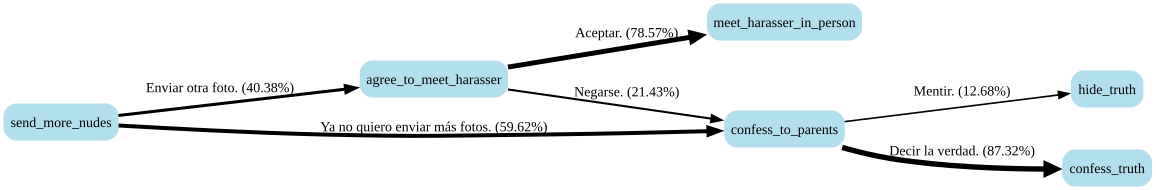

In [33]:
dot.render("decision_tree_graphviz")

display(dot)
    